In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Dashboard_AutoTec") \
    .getOrCreate()

# =====================
# CARGAR DATOS FINALES
# =====================

ruta_datos = "/home/jovyan/work/autotec/datos_etiquetados_kmeans_autotec"

df_completos = spark.read.parquet(ruta_datos)

print("Carga exitosa")

print("Total registros:")
print(df_completos.count())

df_completos.printSchema()

df_completos.show(5)

Carga exitosa
Total registros:
1988
root
 |-- precio: double (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- combustible_limpio: string (nullable = true)
 |-- marca_limpia: string (nullable = true)
 |-- modelo_limpio: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- cat_marca: integer (nullable = true)
 |-- cat_modelo: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)

+-------+-----------+----+------------------+------------+--------------------+---------------+---------+----------+--------------------+--------------------+----------+
| precio|kilometraje|anio|combustible_limpio|marca_limpia|       modelo_limpio|cat_combustible|cat_marca|cat_modelo|            features|      scaledFeatures|prediction|
+-------+-----------+----+------------------+------------+--------------------+---------------+----

In [9]:
print(df_completos.columns)


['precio', 'kilometraje', 'anio', 'combustible_limpio', 'marca_limpia', 'modelo_limpio', 'cat_combustible', 'cat_marca', 'cat_modelo', 'features', 'scaledFeatures', 'prediction']


In [11]:
# NIVEL 1: ESTRATÉGICO

total_autos = df_completos.count()

kpi_estrategico = df_completos.groupBy("marca_limpia") \
    .agg(
        F.count("*").alias("Cantidad_Vehiculos"),
        F.round((F.count("*") / total_autos) * 100, 2).alias("Participacion_Porcentaje"),
        F.round(F.avg("precio"), 0).alias("Precio_Promedio")
    ) \
    .orderBy(F.desc("Cantidad_Vehiculos"))

print("[KPI ESTRATÉGICO] - PARTICIPACIÓN DEL MERCADO POR MARCA")
kpi_estrategico.show()

[KPI ESTRATÉGICO] - PARTICIPACIÓN DEL MERCADO POR MARCA
+------------+------------------+------------------------+---------------+
|marca_limpia|Cantidad_Vehiculos|Participacion_Porcentaje|Precio_Promedio|
+------------+------------------+------------------------+---------------+
|   chevrolet|               178|                    8.95|    1.5602191E7|
|        ford|               174|                    8.75|    2.4979799E7|
|     peugeot|               152|                    7.65|    1.4293085E7|
|      toyota|               131|                    6.59|    1.9984007E7|
|      nissan|               120|                    6.04|    1.5089875E7|
|     hyundai|               103|                    5.18|    1.3284757E7|
|       chery|                99|                    4.98|    1.1887172E7|
|  volkswagen|                83|                    4.18|     1.387241E7|
|          mg|                67|                    3.37|      9447761.0|
|         kia|                66|           

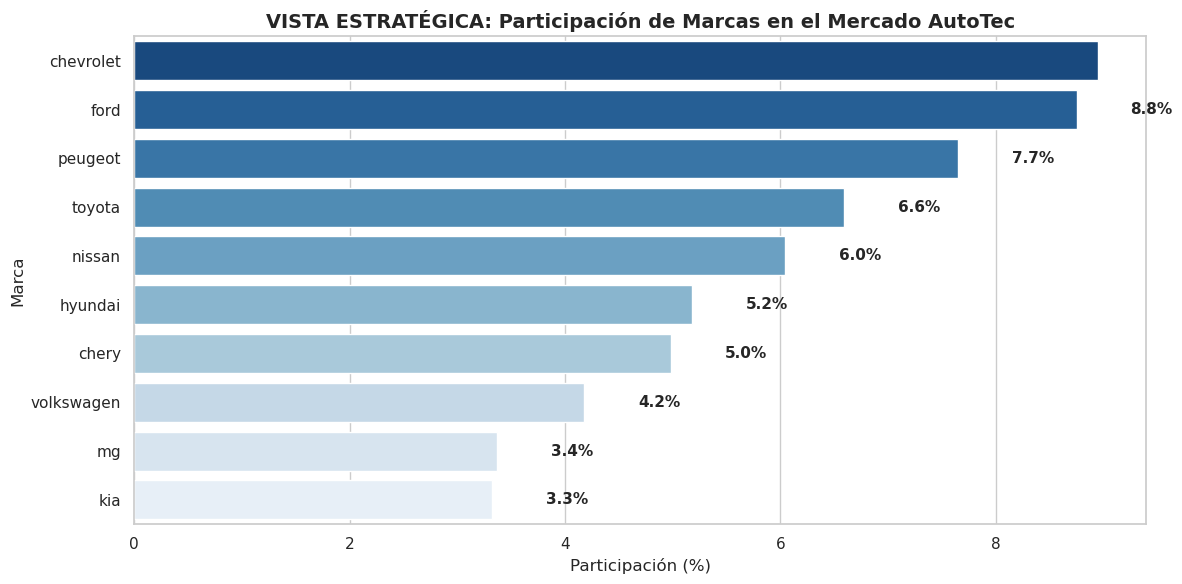

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_est_pandas = kpi_estrategico.toPandas().head(10)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="Participacion_Porcentaje",
    y="marca_limpia",
    data=df_est_pandas,
    hue="marca_limpia",
    palette="Blues_r",
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("VISTA ESTRATÉGICA: Participación de Marcas en el Mercado AutoTec", fontsize=14, fontweight="bold")
plt.xlabel("Participación (%)")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

In [13]:
# ====================================
# NIVEL 2: TÁCTICO
# MATRIZ DE COMPETITIVIDAD DE PRECIOS
# ====================================

kpi_tactico = df_completos.groupBy("marca_limpia") \
    .agg(
        F.round(F.min("precio"),0).alias("Precio_Minimo"),
        F.round(F.avg("precio"),0).alias("Precio_Promedio"),
        F.round(F.max("precio"),0).alias("Precio_Maximo"),
        F.round(F.stddev("precio"),0).alias("Desviacion")
    ) \
    .orderBy(F.desc("Precio_Promedio"))

print("[KPI TÁCTICO] - MATRIZ DE COMPETITIVIDAD")
kpi_tactico.show()

[KPI TÁCTICO] - MATRIZ DE COMPETITIVIDAD
+------------+-------------+---------------+-------------+-----------+
|marca_limpia|Precio_Minimo|Precio_Promedio|Precio_Maximo| Desviacion|
+------------+-------------+---------------+-------------+-----------+
|       lexus|      1.399E7|       3.2471E7|       5.39E7|1.3763176E7|
|         bmw|      1.049E7|    3.1775854E7|      7.999E7|1.7912182E7|
|    mercedes|    8290000.0|      3.06144E7|      8.197E7|1.8140016E7|
|        land|      1.459E7|     3.001625E7|      4.297E7|  8858629.0|
|        audi|       1.15E7|    2.9957105E7|     1.0499E8|1.8840489E7|
|  land-rover|      1.649E7|    2.7156667E7|      3.999E7|1.1898879E7|
|     porsche|       2.25E7|       2.6676E7|      3.599E7|  5314963.0|
|       cupra|      2.399E7|        2.599E7|      2.799E7|  2828427.0|
|        mini|      1.149E7|        2.516E7|      3.199E7|  7539832.0|
|        ford|    6990000.0|    2.4979799E7|      8.499E7|1.3873849E7|
|      jaguar|       1.99E7|        

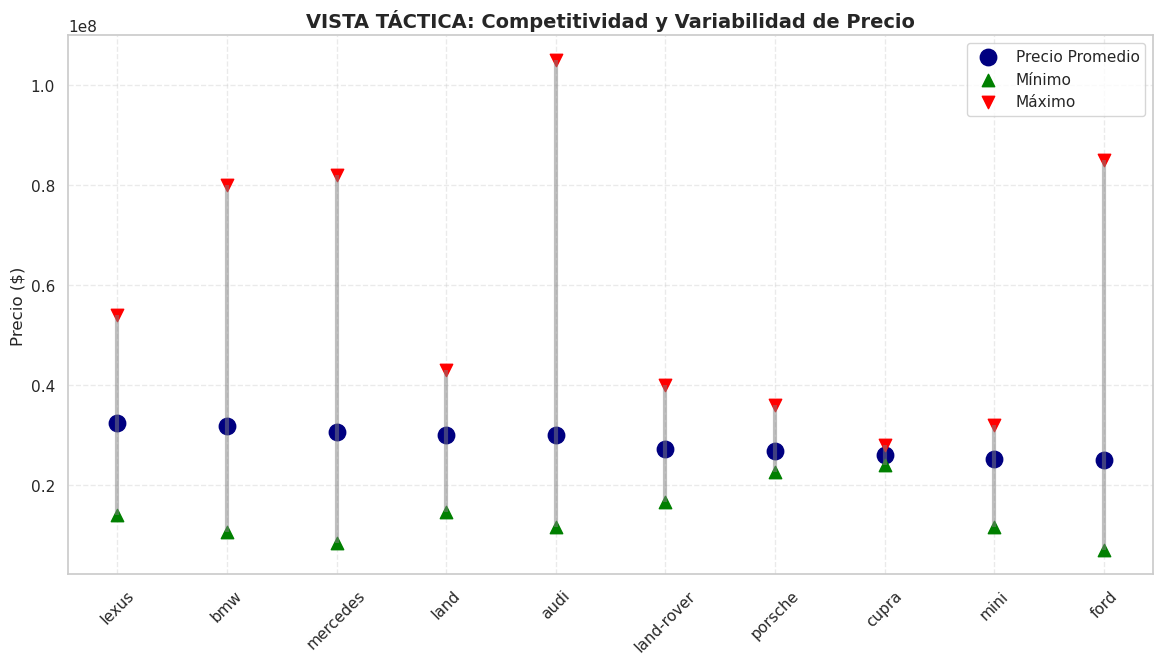

In [14]:
import matplotlib.pyplot as plt

df_tac = kpi_tactico.toPandas().head(10)

plt.figure(figsize=(14,7))

plt.vlines(
    x=df_tac["marca_limpia"],
    ymin=df_tac["Precio_Minimo"],
    ymax=df_tac["Precio_Maximo"],
    color="gray",
    alpha=0.5,
    linewidth=3
)

plt.scatter(
    df_tac["marca_limpia"],
    df_tac["Precio_Promedio"],
    s=140,
    color="navy",
    label="Precio Promedio"
)

plt.scatter(
    df_tac["marca_limpia"],
    df_tac["Precio_Minimo"],
    color="green",
    marker="^",
    s=80,
    label="Mínimo"
)

plt.scatter(
    df_tac["marca_limpia"],
    df_tac["Precio_Maximo"],
    color="red",
    marker="v",
    s=80,
    label="Máximo"
)

plt.title(
    "VISTA TÁCTICA: Competitividad y Variabilidad de Precio",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Precio ($)")
plt.xticks(rotation=45)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.show()

In [15]:
# ====================================
# NIVEL 3: OPERACIONAL
# ALERTAS DE DEPRECIACIÓN
# ====================================

kpi_operacional = df_completos.filter(
    (F.col("kilometraje") >= 120000) |
    (F.col("anio") <= 2014)
)

print("[KPI OPERACIONAL] - VEHÍCULOS CON ALTA DEPRECIACIÓN")
print("Total vehículos en alerta:", kpi_operacional.count())

kpi_operacional.select(
    "marca_limpia",
    "modelo_limpio",
    "anio",
    "kilometraje",
    "precio",
    "prediction"
).show()

[KPI OPERACIONAL] - VEHÍCULOS CON ALTA DEPRECIACIÓN
Total vehículos en alerta: 318
+------------+--------------------+----+-----------+---------+----------+
|marca_limpia|       modelo_limpio|anio|kilometraje|   precio|prediction|
+------------+--------------------+----+-----------+---------+----------+
|        audi|        a6 2.0 turbo|2015|   182000.0|  1.297E7|         1|
|         bmw|           x1 sdrive|2018|   165500.0|  1.597E7|         0|
|         bmw|            x5 m 4.4|2013|    90000.0|   3.29E7|         0|
|   chevrolet|   montana ii rc 1.8|2011|   163238.0|4990000.0|         1|
|        audi|q7 2.0 tfsi quatt...|2018|   121130.0|  2.799E7|         0|
|         bmw|                 325|2011|    98849.0|  1.049E7|         1|
|         bmw|   x1 sdrive 20i 2.0|2015|   200387.0|   1.38E7|         1|
|         bmw|x5 xdrive 35i 3.0...|2017|   123400.0|  2.447E7|         0|
|         bmw|650 cabriolet 4.8 v8|2009|   135000.0|  1.997E7|         1|
|   chevrolet|d-max e5 dcab 4

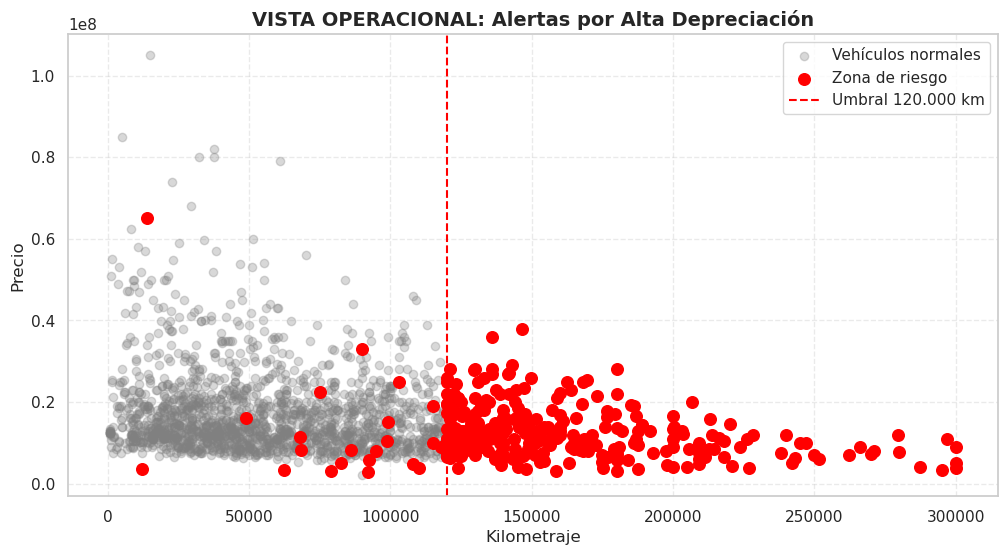

In [16]:
import matplotlib.pyplot as plt

df_op = df_completos.select(
    "marca_limpia",
    "modelo_limpio",
    "anio",
    "kilometraje",
    "precio",
    "prediction"
).toPandas()

df_riesgo = df_op[
    (df_op["kilometraje"] >= 120000) |
    (df_op["anio"] <= 2014)
]

plt.figure(figsize=(12,6))

plt.scatter(
    df_op["kilometraje"],
    df_op["precio"],
    alpha=0.3,
    color="gray",
    label="Vehículos normales"
)

plt.scatter(
    df_riesgo["kilometraje"],
    df_riesgo["precio"],
    color="red",
    s=70,
    label="Zona de riesgo"
)

plt.axvline(
    120000,
    color="red",
    linestyle="--",
    label="Umbral 120.000 km"
)

plt.title(
    "VISTA OPERACIONAL: Alertas por Alta Depreciación",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Kilometraje")
plt.ylabel("Precio")
plt.legend()
plt.grid(linestyle="--", alpha=0.4)
plt.show()

In [17]:
# ====================================
# ACTO 2: DESCUBRIMIENTO DEL MERCADO
# SEGMENTACIÓN K-MEANS AUTOTEC
# ====================================

import pyspark.sql.functions as F

total_registros = df_completos.count()

resumen_clusters = df_completos.groupBy("prediction") \
    .agg(
        F.count("*").alias("Cantidad_Vehiculos"),
        F.round((F.count("*") / total_registros) * 100, 2).alias("Porcentaje_Mercado"),
        F.round(F.avg("precio"), 0).alias("Precio_Promedio"),
        F.round(F.avg("kilometraje"), 0).alias("Kilometraje_Promedio"),
        F.round(F.avg("anio"), 0).alias("Anio_Promedio")
    ) \
    .orderBy("prediction")

print("Tabla 1: Resumen del resultado del clúster")
resumen_clusters.show()

Tabla 1: Resumen del resultado del clúster
+----------+------------------+------------------+---------------+--------------------+-------------+
|prediction|Cantidad_Vehiculos|Porcentaje_Mercado|Precio_Promedio|Kilometraje_Promedio|Anio_Promedio|
+----------+------------------+------------------+---------------+--------------------+-------------+
|         0|               401|             20.17|    1.5811998E7|             64661.0|       2021.0|
|         1|               385|             19.37|    1.1608831E7|            140042.0|       2016.0|
|         2|               158|              7.95|    4.1800506E7|             42266.0|       2023.0|
|         3|              1044|             52.52|    1.4644922E7|             52455.0|       2023.0|
+----------+------------------+------------------+---------------+--------------------+-------------+



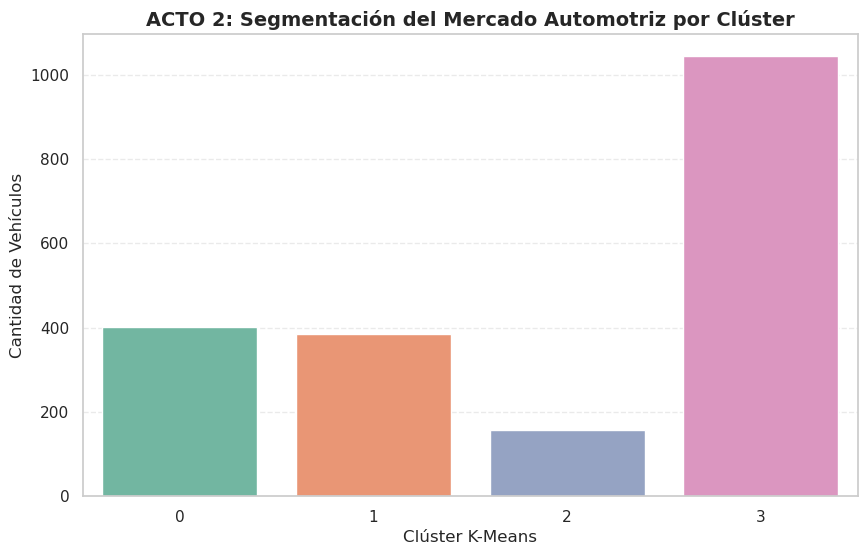

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clusters_pandas = resumen_clusters.toPandas()

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_clusters_pandas,
    x="prediction",
    y="Cantidad_Vehiculos",
    hue="prediction",
    palette="Set2",
    legend=False
)

plt.title(
    "ACTO 2: Segmentación del Mercado Automotriz por Clúster",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Clúster K-Means")
plt.ylabel("Cantidad de Vehículos")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

Al observar la tabla de segmentación, se identifican cuatro grupos de vehículos con comportamientos distintos de depreciación.  
Cada clúster representa un segmento del mercado automotriz usado según precio, kilometraje, año de fabricación, marca y modelo.

Los clústeres con menor precio promedio y mayor kilometraje representan vehículos con mayor depreciación.  
En cambio, los clústeres con mayor precio promedio, menor kilometraje y años más recientes representan vehículos de mayor valor comercial.

In [19]:
df_completos.toPandas().to_csv(
    "/home/jovyan/work/autotec/semana 15/datos_autotec_dashboard.csv",
    index=False
)